In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import f_classif, chi2
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/BRFSS_Diabetes_MedicalOnly.csv')
target = 'HasDiabetes'
features = [col for col in df.columns if col != target]
print(f"Total features: {len(features)}")

Total features: 48


## Diabetics

### Feature Identification (Binary and Numerical)

In [2]:
# Identify binary features (0/1 flags)
binary_features = []
numerical_features = []

for col in features:
    unique_vals = df[col].dropna().unique()
    if set(np.round(unique_vals, 6)).issubset({0, 1}):  # Handle float 0.0/1.0
        binary_features.append(col)
    else:
        numerical_features.append(col)

print(f"Binary features: {len(binary_features)}")
print(f"Numerical features: {len(numerical_features)}")

Binary features: 21
Numerical features: 27


In [3]:
# For statistical tests, we need complete data
# We'll impute temporarily (median for numerical, 0 for binary)

X_bin = df[binary_features].fillna(0)  # Safe for binary flags
X_num = df[numerical_features].copy()
for col in numerical_features:
    X_num[col] = X_num[col].fillna(X_num[col].median())

y = df[target]

### Chi-Square test


 Significant binary features (p < 0.01): 18

ALL SIGNIFICANT BINARY FEATURES (p < 0.01)
                  feature  chi2_score   p_value
            has_arthritis     7132.70  0.00e+00
         ARTHDIS2_missing     6555.79  0.00e+00
meets_strength_guidelines     5934.98  0.00e+00
             low_ses_flag     5170.49  0.00e+00
 meets_aerobic_guidelines     2566.59  0.00e+00
    any_physical_activity     2566.59  0.00e+00
 arthritis_manages_weight     2439.74  0.00e+00
           current_asthma     2406.94  0.00e+00
      arthritis_exercises     1469.70  0.00e+00
          ever_hiv_tested     1173.04 4.42e-257
          ASTHNOW_missing      353.75  6.48e-79
           current_smoker      150.57  1.30e-34
            had_mammogram      140.65  1.92e-32
         HADSGCO1_missing       77.99  1.04e-18
  asthma_attack_past_year       76.29  2.45e-18
             uses_inhaler       53.16  3.08e-13
      had_colon_screening       42.40  7.43e-11
             had_pap_test       12.48  4.10e-04

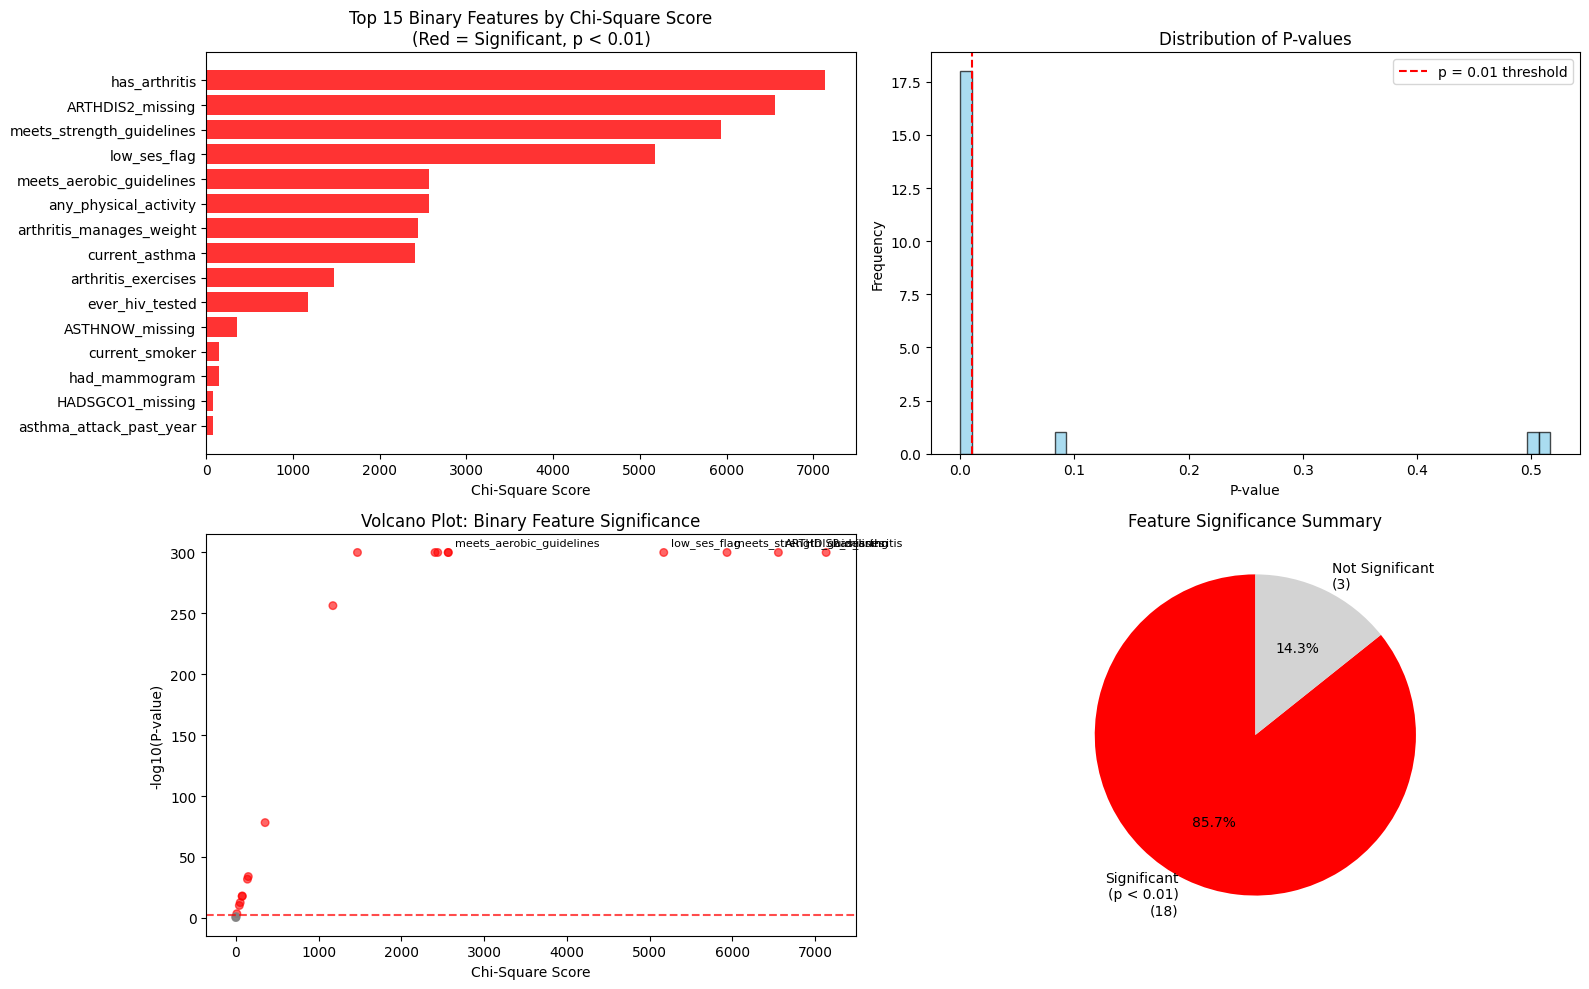


 Advanced visualization saved to: ../results/chi2_binary_analysis.png

 Final significant binary features for modeling (18):
 1. has_arthritis
 2. ARTHDIS2_missing
 3. meets_strength_guidelines
 4. low_ses_flag
 5. meets_aerobic_guidelines
 6. any_physical_activity
 7. arthritis_manages_weight
 8. current_asthma
 9. arthritis_exercises
10. ever_hiv_tested
11. ASTHNOW_missing
12. current_smoker
13. had_mammogram
14. HADSGCO1_missing
15. asthma_attack_past_year
16. uses_inhaler
17. had_colon_screening
18. had_pap_test


In [4]:
# Run Chi-Square test
try:
    chi2_scores, chi2_pvals = chi2(X_bin, y)
except ValueError as e:
    print(f"Chi2 error: {e}")
    # Fallback: manually compute for problematic features
    chi2_scores = []
    chi2_pvals = []
    for col in X_bin.columns:
        try:
            score, pval = chi2(X_bin[[col]], y)
            chi2_scores.append(score[0])
            chi2_pvals.append(pval[0])
        except:
            chi2_scores.append(0)
            chi2_pvals.append(1.0)

# Create results dataframe
chi2_results = pd.DataFrame({
    'feature': X_bin.columns,
    'chi2_score': chi2_scores,
    'p_value': chi2_pvals
}).sort_values('chi2_score', ascending=False)

# Add significance flag
chi2_results['significant'] = chi2_results['p_value'] < 0.01

# Get significant features
significant_binary = chi2_results[chi2_results['significant']]['feature'].tolist()
print(f"\n Significant binary features (p < 0.01): {len(significant_binary)}")

# Display ALL significant features
if significant_binary:
    print("\n" + "="*80)
    print("ALL SIGNIFICANT BINARY FEATURES (p < 0.01)")
    print("="*80)
    significant_df = chi2_results[chi2_results['significant']].copy()
    # Format for better readability
    significant_df['chi2_score'] = significant_df['chi2_score'].round(2)
    significant_df['p_value'] = significant_df['p_value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
    print(significant_df[['feature', 'chi2_score', 'p_value']].to_string(index=False))
else:
    print("No significant binary features found!")

# Save results to CSV
chi2_results.to_csv('../results/chi2_binary_features.csv', index=False)
print(f"\n Chi-Square results saved to: ../results/chi2_binary_features.csv")

# Advanced Visualization
plt.figure(figsize=(16, 10))

# Plot 1: Top 15 features by Chi2 score
plt.subplot(2, 2, 1)
top_15 = chi2_results.head(15)
colors = ['red' if sig else 'lightgray' for sig in top_15['significant']]
bars = plt.barh(range(len(top_15)), top_15['chi2_score'], color=colors, alpha=0.8)
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Chi-Square Score')
plt.title('Top 15 Binary Features by Chi-Square Score\n(Red = Significant, p < 0.01)')
plt.gca().invert_yaxis()

# Plot 2: P-value distribution
plt.subplot(2, 2, 2)
plt.hist(chi2_results['p_value'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(0.01, color='red', linestyle='--', label='p = 0.01 threshold')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.title('Distribution of P-values')
plt.legend()

# Plot 3: Volcano plot (Chi2 score vs -log10(p-value))
plt.subplot(2, 2, 3)
chi2_results_plot = chi2_results.copy()
chi2_results_plot['neg_log10_pval'] = -np.log10(chi2_results_plot['p_value'].clip(lower=1e-300))  # Avoid log(0)
colors = ['red' if sig else 'gray' for sig in chi2_results_plot['significant']]

plt.scatter(chi2_results_plot['chi2_score'], chi2_results_plot['neg_log10_pval'], 
           c=colors, alpha=0.6, s=30)
plt.xlabel('Chi-Square Score')
plt.ylabel('-log10(P-value)')
plt.title('Volcano Plot: Binary Feature Significance')
plt.axhline(-np.log10(0.01), color='red', linestyle='--', alpha=0.7)

# Add labels for top significant features
top_sig = chi2_results_plot[chi2_results_plot['significant']].nlargest(5, 'chi2_score')
for idx, row in top_sig.iterrows():
    plt.annotate(row['feature'], (row['chi2_score'], row['neg_log10_pval']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot 4: Feature significance summary
plt.subplot(2, 2, 4)
total_features = len(chi2_results)
significant_count = len(significant_binary)
non_significant = total_features - significant_count

plt.pie([significant_count, non_significant], 
        labels=[f'Significant\n(p < 0.01)\n({significant_count})', 
                f'Not Significant\n({non_significant})'],
        colors=['red', 'lightgray'], autopct='%1.1f%%', startangle=90)
plt.title('Feature Significance Summary')

plt.tight_layout()
plt.savefig('../results/chi2_binary_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Advanced visualization saved to: ../results/chi2_binary_analysis.png")

# Final feature list for modeling
print(f"\n Final significant binary features for modeling ({len(significant_binary)}):")
for i, feature in enumerate(significant_binary, 1):
    print(f"{i:2}. {feature}")

### ANOVA F-test

c:\Users\hasit\OneDrive\Documents\Projects\HealthIntel\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


  Removing target leakage features: ['DIABETE3']

 Significant numerical features (p < 0.01): 25

ALL SIGNIFICANT NUMERICAL FEATURES (p < 0.01)
                  feature  f_score   p_value
     med_conditions_score 91648.49  0.00e+00
                 _RFHYPE5 72687.37  0.00e+00
                age_score 48467.86  0.00e+00
             health_score 47605.36  0.00e+00
                  _RFHLTH 43359.82  0.00e+00
                      BMI 39857.94  0.00e+00
                weight_kg 25284.69  0.00e+00
                 _DRDXAR1 22013.99  0.00e+00
            cv_risk_score 21276.62  0.00e+00
            alcohol_level 20931.85  0.00e+00
                 _CHOLCHK 18472.32  0.00e+00
             income_score 13836.61  0.00e+00
        care_access_score 11805.06  0.00e+00
                edu_score  9456.63  0.00e+00
     strength_freq_weekly  8612.32  0.00e+00
                 _ASTHMS1  2763.03  0.00e+00
                 _CASTHM1  2724.60  0.00e+00
                 _LTASTH1  2404.57  0.00e+00
 

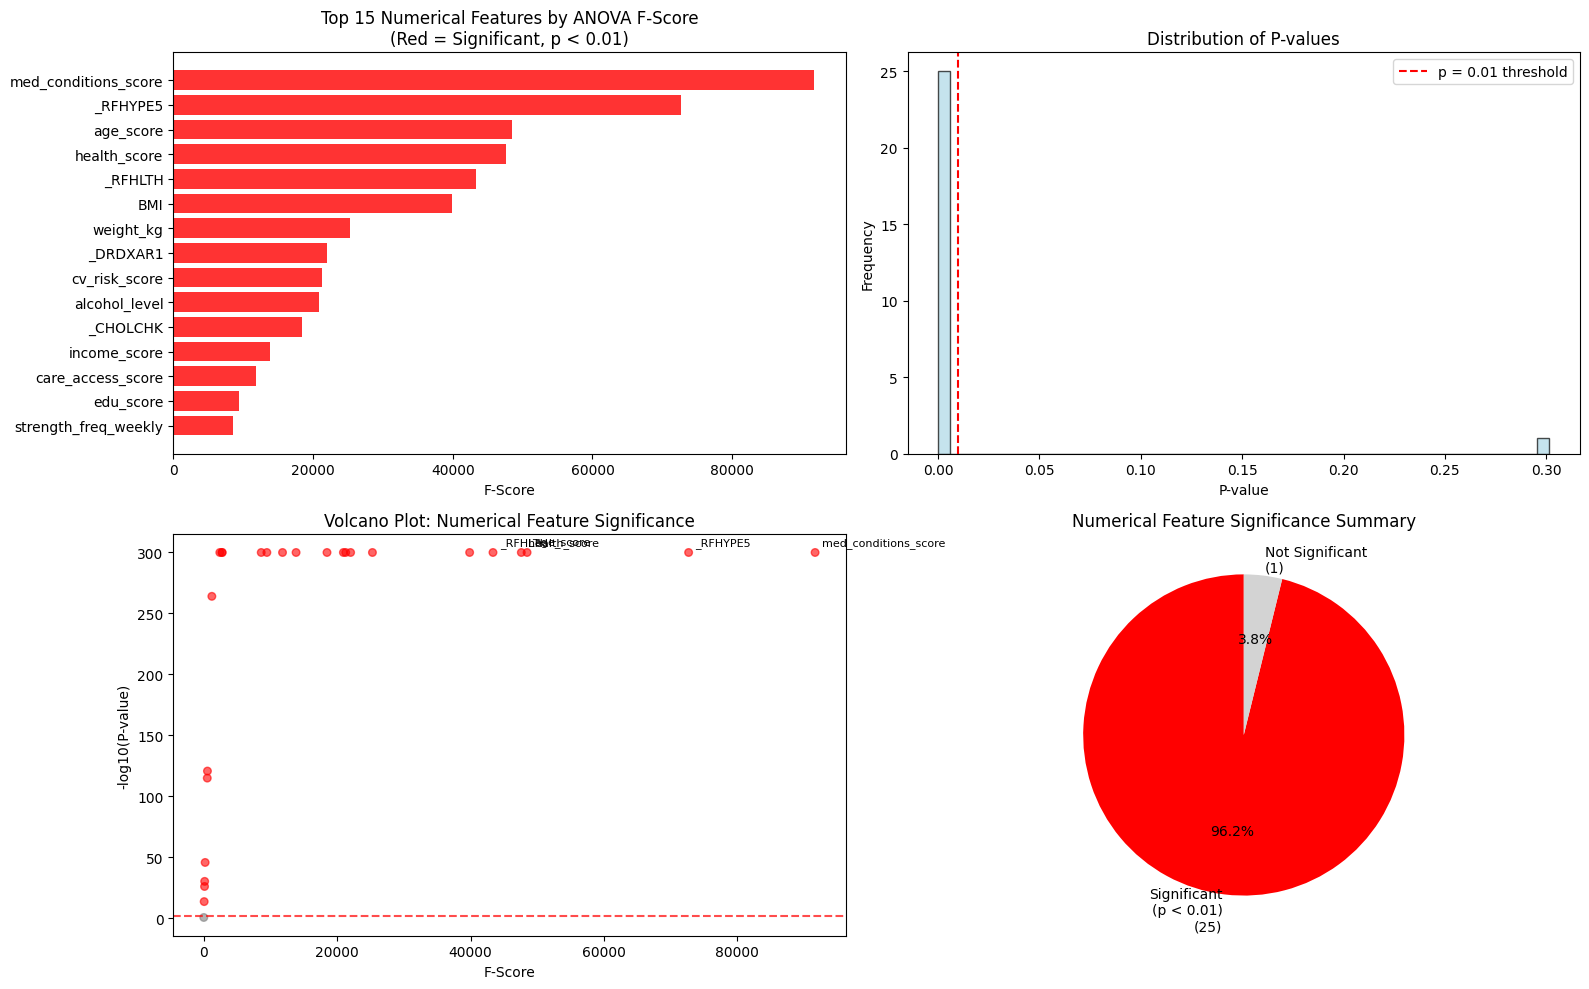


 Advanced visualization saved to: ../results/anova_numerical_analysis.png

 Final significant numerical features for modeling (25):
 1. med_conditions_score
 2. _RFHYPE5
 3. age_score
 4. health_score
 5. _RFHLTH
 6. BMI
 7. weight_kg
 8. _DRDXAR1
 9. cv_risk_score
10. alcohol_level
11. _CHOLCHK
12. income_score
13. care_access_score
14. edu_score
15. strength_freq_weekly
16. _ASTHMS1
17. _CASTHM1
18. _LTASTH1
19. PADUR1_
20. arthritis_limits_activity
21. height_m
22. diet_score
23. smoking_status
24. SEX
25. PAFREQ1_


In [5]:
# Run ANOVA F-test
try:
    f_scores, f_pvals = f_classif(X_num, y)
except ValueError as e:
    print(f"ANOVA error: {e}")
    # Fallback: compute feature by feature
    f_scores = []
    f_pvals = []
    for col in X_num.columns:
        try:
            score, pval = f_classif(X_num[[col]], y)
            f_scores.append(score[0])
            f_pvals.append(pval[0])
        except:
            f_scores.append(0)
            f_pvals.append(1.0)

# Create results dataframe
anova_results = pd.DataFrame({
    'feature': X_num.columns,
    'f_score': f_scores,
    'p_value': f_pvals
}).sort_values('f_score', ascending=False)

# Handle infinite F-scores (perfect separation)
anova_results['f_score'] = anova_results['f_score'].replace([np.inf, -np.inf], 1e6)

# Add significance flag
anova_results['significant'] = anova_results['p_value'] < 0.01

# Remove target leakage features (CRITICAL!)
leakage_features = ['DIABETE3', 'PREDIAB1', 'INSULIN', 'CHKHEMO3', 'DOCTDIAB', 'DIABAGE2']
leakage_in_results = [f for f in leakage_features if f in anova_results['feature'].values]
if leakage_in_results:
    print(f"  Removing target leakage features: {leakage_in_results}")
    anova_results = anova_results[~anova_results['feature'].isin(leakage_features)]

# Get significant features
significant_numerical = anova_results[anova_results['significant']]['feature'].tolist()
print(f"\n Significant numerical features (p < 0.01): {len(significant_numerical)}")

# Display ALL significant features
if significant_numerical:
    print("\n" + "="*80)
    print("ALL SIGNIFICANT NUMERICAL FEATURES (p < 0.01)")
    print("="*80)
    significant_df = anova_results[anova_results['significant']].copy()
    # Format for better readability
    significant_df['f_score'] = significant_df['f_score'].apply(lambda x: f"{x:.2f}" if x < 1e5 else "inf")
    significant_df['p_value'] = significant_df['p_value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
    print(significant_df[['feature', 'f_score', 'p_value']].to_string(index=False))
else:
    print("No significant numerical features found!")

# Save results to CSV
anova_results.to_csv('../results/anova_numerical_features.csv', index=False)
print(f"\n ANOVA results saved to: ../results/anova_numerical_features.csv")

# Advanced Visualization
plt.figure(figsize=(16, 10))

# Plot 1: Top 15 features by F-score
plt.subplot(2, 2, 1)
top_15 = anova_results.head(15)
colors = ['red' if sig else 'lightgray' for sig in top_15['significant']]
bars = plt.barh(range(len(top_15)), top_15['f_score'], color=colors, alpha=0.8)
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('F-Score')
plt.title('Top 15 Numerical Features by ANOVA F-Score\n(Red = Significant, p < 0.01)')
plt.gca().invert_yaxis()

# Plot 2: P-value distribution
plt.subplot(2, 2, 2)
plt.hist(anova_results['p_value'], bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.axvline(0.01, color='red', linestyle='--', label='p = 0.01 threshold')
plt.xlabel('P-value')
plt.ylabel('Frequency')
plt.title('Distribution of P-values')
plt.legend()

# Plot 3: Volcano plot (F-score vs -log10(p-value))
plt.subplot(2, 2, 3)
anova_plot = anova_results.copy()
anova_plot['neg_log10_pval'] = -np.log10(anova_plot['p_value'].clip(lower=1e-300))
colors = ['red' if sig else 'gray' for sig in anova_plot['significant']]

plt.scatter(anova_plot['f_score'], anova_plot['neg_log10_pval'], 
           c=colors, alpha=0.6, s=30)
plt.xlabel('F-Score')
plt.ylabel('-log10(P-value)')
plt.title('Volcano Plot: Numerical Feature Significance')
plt.axhline(-np.log10(0.01), color='red', linestyle='--', alpha=0.7)

# Add labels for top significant features
top_sig = anova_plot[anova_plot['significant']].nlargest(5, 'f_score')
for idx, row in top_sig.iterrows():
    plt.annotate(row['feature'], (row['f_score'], row['neg_log10_pval']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Plot 4: Feature significance summary
plt.subplot(2, 2, 4)
total_features = len(anova_results)
significant_count = len(significant_numerical)
non_significant = total_features - significant_count

plt.pie([significant_count, non_significant], 
        labels=[f'Significant\n(p < 0.01)\n({significant_count})', 
                f'Not Significant\n({non_significant})'],
        colors=['red', 'lightgray'], autopct='%1.1f%%', startangle=90)
plt.title('Numerical Feature Significance Summary')

plt.tight_layout()
plt.savefig('../results/anova_numerical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Advanced visualization saved to: ../results/anova_numerical_analysis.png")

# Final feature list for modeling
print(f"\n Final significant numerical features for modeling ({len(significant_numerical)}):")
for i, feature in enumerate(significant_numerical, 1):
    print(f"{i:2}. {feature}")
